In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

import pyswarms as ps
from deap import base, creator, tools, algorithms

In [3]:
df = pd.read_csv("cleandata.csv")
data = df.iloc[:, 1].values.reshape(-1, 1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

In [4]:
def create_dataset(dataset, time_step=10):
    X, y = [], []
    for i in range(len(dataset) - time_step):
        X.append(dataset[i:(i + time_step), 0])
        y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 10
X, y = create_dataset(data_scaled, time_step)

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [5]:
def build_tcn(filters, kernel_size, lr):
    model = Sequential()
    model.add(Dense(filters, input_shape=(time_step,), activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

In [6]:
def evaluate(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(f"\n{name} Performance:")
    print(f"MAE: {mae}")
    print(f"RMSE: {rmse}")
    print(f"R2: {r2}")

In [7]:
def objective_function(params):
    results = []
    for p in params:
        filters = int(p[0])
        kernel = int(p[1])
        lr = p[2]

        model = build_tcn(filters, kernel, lr)
        model.fit(X_train, y_train, epochs=5, verbose=0)

        pred = model.predict(X_test)
        loss = np.mean((pred - y_test.reshape(-1,1))**2)
        results.append(loss)
    return np.array(results)

bounds = ([16, 2, 0.0001], [128, 5, 0.01])
optimizer = ps.single.GlobalBestPSO(
    n_particles=5,
    dimensions=3,
    options={'c1':0.5, 'c2':0.3, 'w':0.9},
    bounds=bounds
)

best_cost, best_pos = optimizer.optimize(objective_function, iters=10)

pso_filters = int(best_pos[0])
pso_kernel = int(best_pos[1])
pso_lr = best_pos[2]

print("\n=== PSO-TCN Final Optimized Hyperparameters ===")
print(pso_filters, pso_kernel, pso_lr)

2026-04-18 04:58:52,474 - pyswarms.single.global_best - INFO - Optimize for 10 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best:   0%|                                                                                                                        |0/10

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-04-18 04:58:52,604 - tensorflow - WARNING - TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.


325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 703us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 708us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step


pyswarms.single.global_best:  10%|██████████                                                                                           |1/10, best_cost=0.00468

325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 689us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 678us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 690us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 712us/step


...

325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step


pyswarms.single.global_best:  90%|██████████████████████████████████████████████████████████████████████████████████████████▉          |9/10, best_cost=0.00425

325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 702us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 694us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 686us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 680us/step


pyswarms.single.global_best: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████|10/10, best_cost=0.00425
2026-04-18 05:04:38,598 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.004251848004686712, best pos: [4.97659126e+01 2.98261760e+00 3.79403090e-03]



=== PSO-TCN Final Optimized Hyperparameters ===
49 2 0.0037940309033332492


In [8]:
# Train PSO model
pso_model = build_tcn(pso_filters, pso_kernel, pso_lr)
pso_model.fit(X_train, y_train, epochs=20, verbose=0)
pso_pred = scaler.inverse_transform(pso_model.predict(X_test))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1,1))

325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 683us/step


In [9]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()
toolbox.register("filters", np.random.randint, 16, 128)
toolbox.register("kernel", np.random.randint, 2, 5)
toolbox.register("lr", np.random.uniform, 0.0001, 0.01)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.filters, toolbox.kernel, toolbox.lr), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def eval_individual(ind):
    model = build_tcn(int(ind[0]), int(ind[1]), ind[2])
    model.fit(X_train, y_train, epochs=5, verbose=0)

    pred = model.predict(X_test)
    return (np.mean((pred - y_test.reshape(-1,1))**2),)

toolbox.register("evaluate", eval_individual)
toolbox.register("mate", tools.cxBlend, alpha=0.5)
toolbox.register("mutate", tools.mutGaussian, mu=0, sigma=1, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

population = toolbox.population(n=5)
algorithms.eaSimple(population, toolbox, cxpb=0.5, mutpb=0.2, ngen=5, verbose=False)

best_ind = tools.selBest(population, k=1)[0]

ga_filters = int(best_ind[0])
ga_kernel = int(best_ind[1])
ga_lr = best_ind[2]

print("\n=== GA-TCN Final Optimized Hyperparameters ===")
print(ga_filters, ga_kernel, ga_lr)

C:\Users\Jerwin Gubat\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 786us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 667us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 692us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 682us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 674us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 672us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 696us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 679us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 705us/step
325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step

=== GA-TCN Final Optimized Hyperparameters ===
9 3 0.0017081327392995144


In [10]:
# Train GA model
ga_model = build_tcn(ga_filters, ga_kernel, ga_lr)
ga_model.fit(X_train, y_train, epochs=20, verbose=0)
ga_pred = scaler.inverse_transform(ga_model.predict(X_test))

325/325 ━━━━━━━━━━━━━━━━━━━━ 0s 699us/step


In [11]:
sarima_order = (1,1,1)
sarima_seasonal_order = (1,1,1,12)

sarima = SARIMAX(data, order=sarima_order, seasonal_order=sarima_seasonal_order)
sarima_fit = sarima.fit(disp=False)

sarima_pred = sarima_fit.predict(start=split, end=len(data)-1)

In [13]:
sarima_aligned = sarima_pred[time_step:].reshape(-1,1)

sarima_aligned = sarima_aligned[:len(pso_pred)]
final_pso = sarima_aligned + pso_pred
final_ga = sarima_aligned + ga_pred

print("\n=== SARIMA-PSO-TCN Final Configuration ===")
print(sarima_order, sarima_seasonal_order, pso_filters, pso_kernel, pso_lr)

print("\n=== SARIMA-GA-TCN Final Configuration ===")
print(sarima_order, sarima_seasonal_order, ga_filters, ga_kernel, ga_lr)


=== SARIMA-PSO-TCN Final Configuration ===
(1, 1, 1) (1, 1, 1, 12) 49 2 0.0037940309033332492

=== SARIMA-GA-TCN Final Configuration ===
(1, 1, 1) (1, 1, 1, 12) 9 3 0.0017081327392995144


In [15]:
actual_aligned = data[split + time_step:]

actual_aligned = actual_aligned[:len(final_pso)]

evaluate("PSO-TCN", y_test_inv, pso_pred)
evaluate("GA-TCN", y_test_inv, ga_pred)
evaluate("SARIMA-PSO-TCN", actual_aligned, final_pso)
evaluate("SARIMA-GA-TCN", actual_aligned, final_ga)


PSO-TCN Performance:
MAE: 10.382934549019286
RMSE: 15.13650901583938
R2: 0.8315720691572297

GA-TCN Performance:
MAE: 10.612310487840057
RMSE: 15.809934632014032
R2: 0.8162519181834144

SARIMA-PSO-TCN Performance:
MAE: 43.42803509329962
RMSE: 57.518981318852234
R2: -1.43212021447526

SARIMA-GA-TCN Performance:
MAE: 41.337271974820155
RMSE: 55.1075990143895
R2: -1.232470068083582


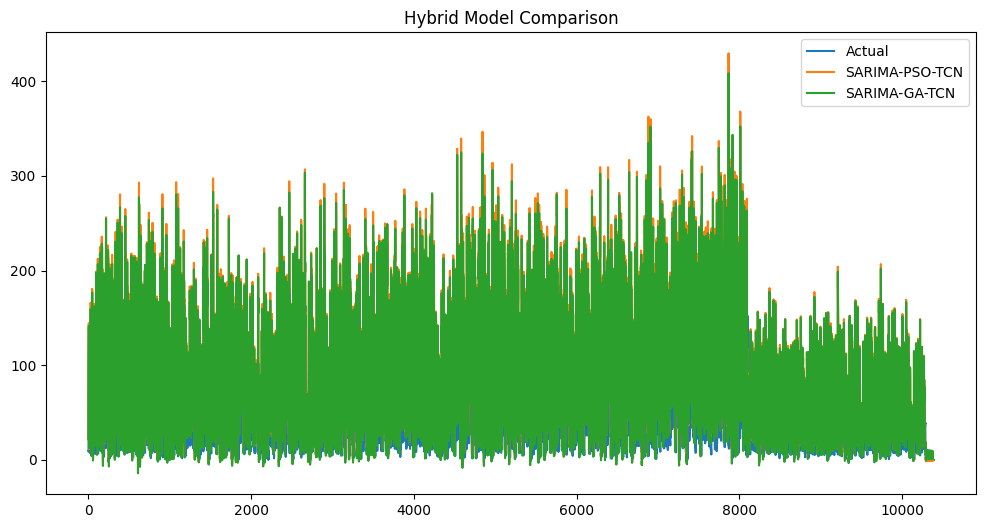

In [16]:
plt.figure(figsize=(12,6))
plt.plot(actual, label="Actual")
plt.plot(final_pso, label="SARIMA-PSO-TCN")
plt.plot(final_ga, label="SARIMA-GA-TCN")
plt.legend()
plt.title("Hybrid Model Comparison")
plt.show()

In [17]:
summary = pd.DataFrame({
    "Model": ["PSO-TCN", "GA-TCN", "SARIMA-PSO-TCN", "SARIMA-GA-TCN"],
    "Filters": [pso_filters, ga_filters, pso_filters, ga_filters],
    "Kernel": [pso_kernel, ga_kernel, pso_kernel, ga_kernel],
    "Learning Rate": [pso_lr, ga_lr, pso_lr, ga_lr]
})

print("\n=== FINAL HYPERPARAMETER SUMMARY ===")
print(summary)


=== FINAL HYPERPARAMETER SUMMARY ===
            Model  Filters  Kernel  Learning Rate
0         PSO-TCN       49       2       0.003794
1          GA-TCN        9       3       0.001708
2  SARIMA-PSO-TCN       49       2       0.003794
3   SARIMA-GA-TCN        9       3       0.001708
